# Lokaliteter — antall og tetthet per PO

Egen notebook for spørsmål om struktur i lokalitetslandskapet, separert fra
`04_extra_charts.py` så vi slipper å re-kjøre alle breach-/temp-figurene
hver gang vi vil legge til en ny analyse.

Bruker den firewall-beskyttede loaderen (`apply_cutoff=True`, < 2026-01-01).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import BallTree

from src.load_data import load_lice
from src.utils import po_label, short_po_name

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
})

FIG_DIR = ROOT / "reports" / "figures" / "Site-forhold"
FIG_DIR.mkdir(parents=True, exist_ok=True)

lice = load_lice()
EARTH_R_KM = 6371.0088

## Chart 1 — Antall aktive lokaliteter per PO i 2024

"Aktiv" = lokalitet med minst én ukentlig observasjon i 2024 (fra `vlice`).
Dette teller alle steder hvor det ble rapportert lus-tall eller status (også
fallow-uker), så det reflekterer hvor mange anlegg som *eksisterte og var
overvåket* — ikke hvor mange som hadde fisk i sjøen til enhver tid.

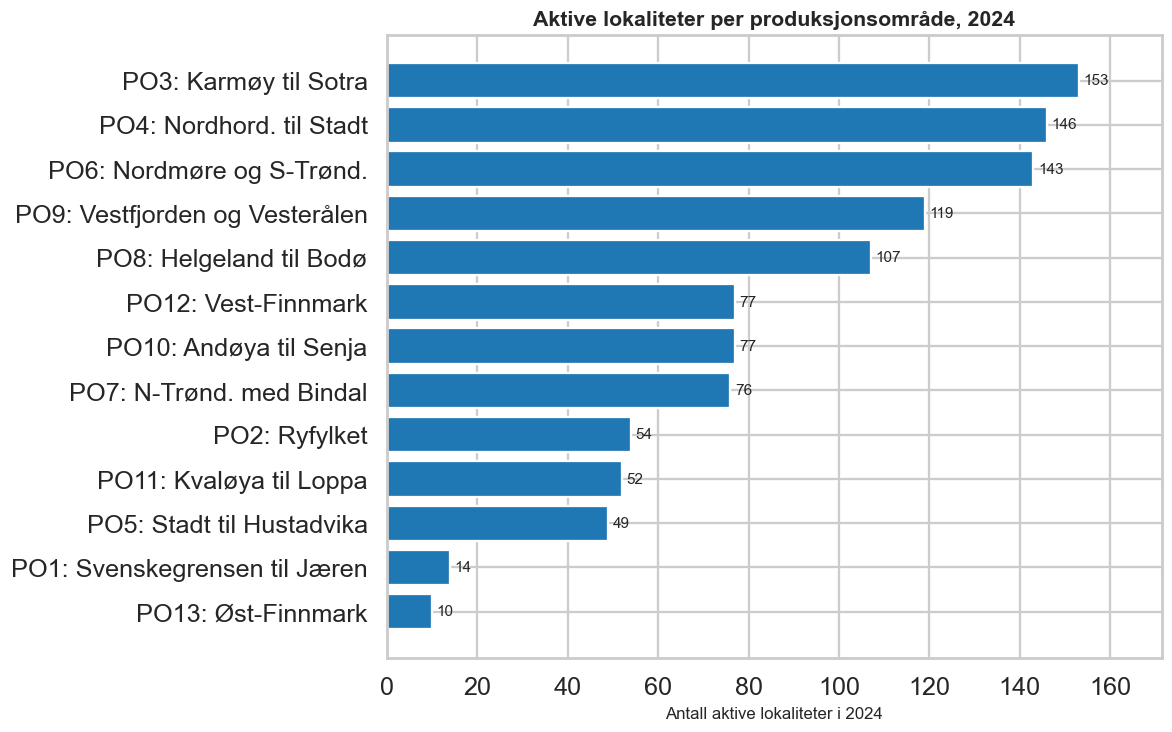


Totalt antall aktive lokaliteter i 2024: 1,077
Snitt per PO: 82.8

Topp 3 PO etter antall lokaliteter:
                    label  n_active_sites
    PO3: Karmøy til Sotra             153
 PO4: Nordhord. til Stadt             146
PO6: Nordmøre og S-Trønd.             143


In [2]:
YEAR = 2024
lice_2024 = lice[lice["WEEK_START"].dt.year == YEAR]

active_per_po = (
    lice_2024.dropna(subset=["PRODUCTIONAREAID"])
    .groupby(["PRODUCTIONAREAID", "PRODUCTIONAREA"])["SITENUMBER"]
    .nunique()
    .rename("n_active_sites")
    .reset_index()
    .sort_values("n_active_sites", ascending=True)
)
active_per_po["label"] = active_per_po.apply(
    lambda r: po_label(r["PRODUCTIONAREAID"], r["PRODUCTIONAREA"]), axis=1
)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(active_per_po["label"], active_per_po["n_active_sites"],
               color="#1f77b4")
ax.bar_label(bars, fmt="%d", padding=3, fontsize=10)
ax.set_xlabel(f"Antall aktive lokaliteter i {YEAR}")
ax.set_title(f"Aktive lokaliteter per produksjonsområde, {YEAR}")
ax.set_xlim(0, active_per_po["n_active_sites"].max() * 1.12)
fig.tight_layout()
fig.savefig(FIG_DIR / f"active_sites_per_po_{YEAR}.png")
plt.show()

total_active = active_per_po["n_active_sites"].sum()
print(f"\nTotalt antall aktive lokaliteter i {YEAR}: {total_active:,}")
print(f"Snitt per PO: {active_per_po['n_active_sites'].mean():.1f}")
print(f"\nTopp 3 PO etter antall lokaliteter:")
print(active_per_po.sort_values("n_active_sites", ascending=False)
      .head(3)[["label", "n_active_sites"]].to_string(index=False))

## Chart 2 — Lokalitetstetthet: PO1-2 vs PO3-4 (2024)

**Spørsmål:** Hvor tett ligger lokalitetene i PO3-4 sammenliknet med PO1-2?

**Mål:** *Nearest-neighbour distance* per lokalitet (km), beregnet med
haversine på lat/lon. For hver lokalitet finner vi nærmeste annen lokalitet
**innenfor samme PO-gruppe** (slik at vi måler tetthet i regionen, ikke
avstand til en lokalitet i en helt annen PO). Dette er det biologisk
relevante målet: lus sprer seg mellom anlegg via vannmasser, så jo nærmere
nabo, jo større smittepress.

To visninger:
1. **Kart** med lokalitetene per gruppe (sanity check).
2. **Box+strip plot** av NN-avstander for hver gruppe.


NN-avstand mellom 2024-lokaliteter, innenfor PO-gruppe:
                                         n_sites  mean_nn_km  median_nn_km  p25_km  p75_km
PO1-2 (Svenskegrensen, Ryfylket)            68.0        4.06          2.77    2.14    4.29
PO3-4 (Karmøy, Nordhordaland til Stadt)    299.0        3.20          3.05    1.93    3.99


C:\Users\joerg\AppData\Local\Temp\ipykernel_32516\4090072099.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=nn_df, x="group", y="nn_km", order=order,


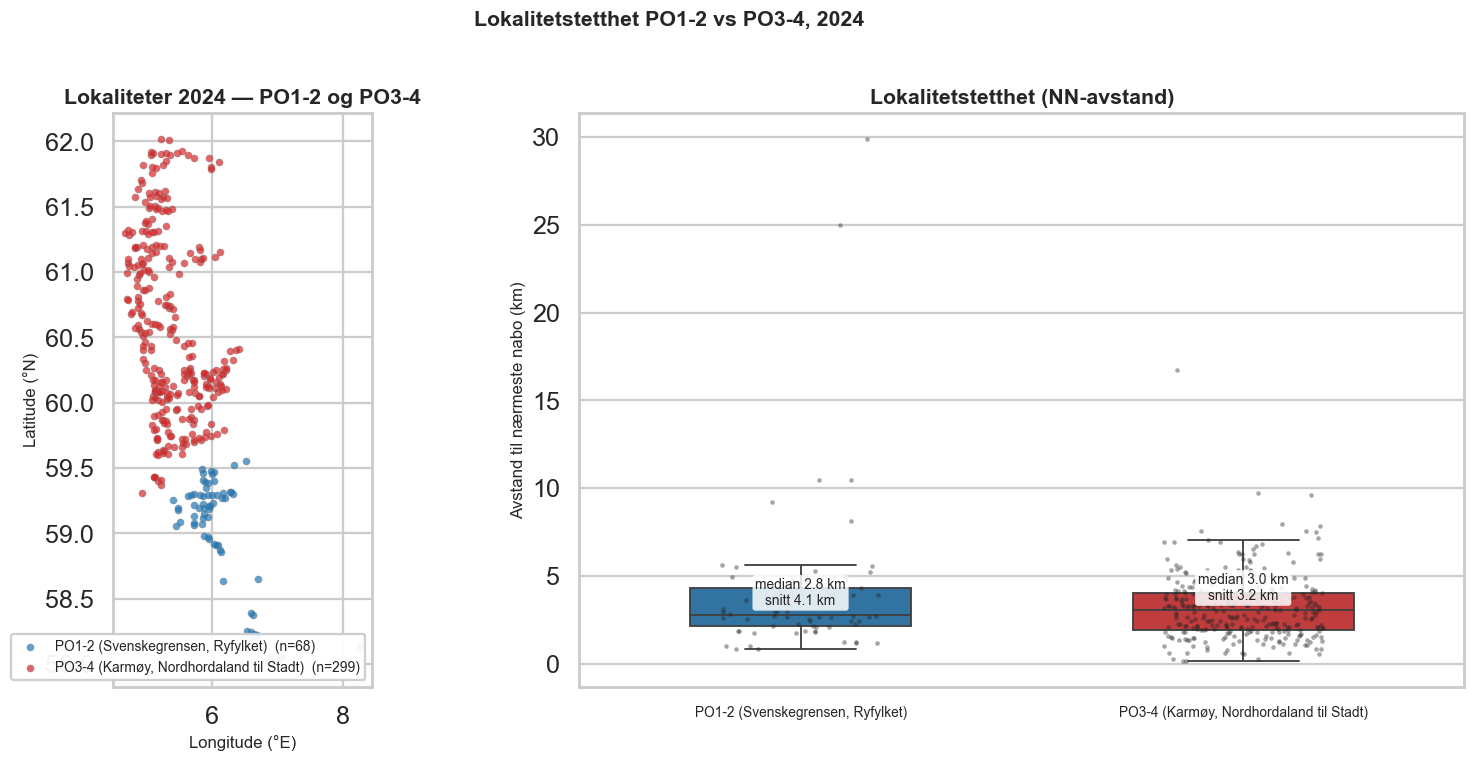

In [3]:
GROUPS = {
    "PO1-2 (Svenskegrensen, Ryfylket)": [1, 2],
    "PO3-4 (Karmøy, Nordhordaland til Stadt)": [3, 4],
}


def nn_distances_km(lat: np.ndarray, lon: np.ndarray) -> np.ndarray:
    """Nearest-neighbour distance in km for each point, using haversine."""
    if len(lat) < 2:
        return np.array([])
    coords_rad = np.radians(np.column_stack([lat, lon]))
    tree = BallTree(coords_rad, metric="haversine")
    # k=2 because the first neighbour is the point itself
    dist_rad, _ = tree.query(coords_rad, k=2)
    return dist_rad[:, 1] * EARTH_R_KM


# Take a single representative lat/lon per active 2024 site (mean across the
# year; lat/lon drift across weeks is <0.01° for ~99.7% of sites per the audit).
sites_2024 = (
    lice_2024.dropna(subset=["LATITUDE", "LONGITUDE", "PRODUCTIONAREAID"])
    .groupby(["SITENUMBER", "PRODUCTIONAREAID"])
    .agg(lat=("LATITUDE", "mean"), lon=("LONGITUDE", "mean"))
    .reset_index()
)

records = []
group_stats = {}
for label, po_ids in GROUPS.items():
    sub = sites_2024[sites_2024["PRODUCTIONAREAID"].isin(po_ids)]
    nn_km = nn_distances_km(sub["lat"].values, sub["lon"].values)
    for d in nn_km:
        records.append({"group": label, "nn_km": d})
    group_stats[label] = {
        "n_sites": len(sub),
        "mean_nn_km": float(np.mean(nn_km)) if len(nn_km) else np.nan,
        "median_nn_km": float(np.median(nn_km)) if len(nn_km) else np.nan,
        "p25_km": float(np.percentile(nn_km, 25)) if len(nn_km) else np.nan,
        "p75_km": float(np.percentile(nn_km, 75)) if len(nn_km) else np.nan,
    }

nn_df = pd.DataFrame(records)
stats_df = pd.DataFrame(group_stats).T.round(2)
print(f"\nNN-avstand mellom 2024-lokaliteter, innenfor PO-gruppe:")
print(stats_df.to_string())

# --- Plot ---
fig, (ax_map, ax_box) = plt.subplots(1, 2, figsize=(15, 7),
                                     gridspec_kw={"width_ratios": [1, 1.2]})

GROUP_COLORS = {
    "PO1-2 (Svenskegrensen, Ryfylket)": "#1f77b4",
    "PO3-4 (Karmøy, Nordhordaland til Stadt)": "#d62728",
}

# Left: simple lat/lon map of the two groups
for label, po_ids in GROUPS.items():
    sub = sites_2024[sites_2024["PRODUCTIONAREAID"].isin(po_ids)]
    ax_map.scatter(sub["lon"], sub["lat"], s=22, alpha=0.7,
                   color=GROUP_COLORS[label], edgecolors="grey",
                   linewidths=0.3, label=f"{label}  (n={len(sub)})")
ax_map.set_xlabel("Longitude (°E)")
ax_map.set_ylabel("Latitude (°N)")
ax_map.set_title("Lokaliteter 2024 — PO1-2 og PO3-4")
ax_map.legend(loc="lower right", fontsize=9, framealpha=0.95)
ax_map.set_aspect(2.0)

# Right: NN distance distribution per group
order = list(GROUPS.keys())
sns.boxplot(data=nn_df, x="group", y="nn_km", order=order,
            ax=ax_box, palette=[GROUP_COLORS[g] for g in order],
            showfliers=False, width=0.5, linewidth=1.2)
sns.stripplot(data=nn_df, x="group", y="nn_km", order=order,
              ax=ax_box, color="#222222", alpha=0.4, size=3, jitter=0.18)
ax_box.set_ylabel("Avstand til nærmeste nabo (km)")
ax_box.set_xlabel("")
ax_box.set_title("Lokalitetstetthet (NN-avstand)")
for i, label in enumerate(order):
    s = group_stats[label]
    ax_box.text(i, s["median_nn_km"] + 0.4,
                f"median {s['median_nn_km']:.1f} km\nsnitt {s['mean_nn_km']:.1f} km",
                ha="center", va="bottom", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                          alpha=0.85, edgecolor="none"))
ax_box.tick_params(axis="x", labelsize=9)

fig.suptitle(f"Lokalitetstetthet PO1-2 vs PO3-4, {YEAR}",
             fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
fig.savefig(FIG_DIR / f"site_density_po1_4_{YEAR}.png")
plt.show()